# Build a supervised model for predicting Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc with a defined applicability domain. It should be able to predict logKoc from a SMILES input and tell the user whether the new molecules fall into its AD. 

#### Tasks:
1) Load the training data
2) Build a supervised model of your choice (e.g., MACCS keys x Random Forest, but feel free to go for something more fancy) on 80% of the training data
3) Use an AD metric of your choice
4) Evaluate model on a 20% test set, and compare the prediction error with your AD metric
5) Predict the Koc and AD for 3 new substances.

In [146]:
# import
from rdkit import Chem
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

from rdkit import Chem
from rdkit.Chem import MACCSkeys
from sklearn.ensemble import RandomForestRegressor
from rdkit import DataStructs

#### 1. Load training data and split into train/test 80/20

In [147]:
# Loading the data from an sdf file
supplier = Chem.SDMolSupplier("KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC']}
    }
    for m in supplier if m is not None
])

In [148]:
df.head()

,SMILES,preferred_name,LogKOC
0,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1,"p,p'-DDT",5.31
1,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,Benzo(a)pyrene,5.95
2,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,Niclosamide,3.35
3,COc1ccc(NC(C)=O)cc1,N-(4-Methoxyphenyl)acetamide,1.4
4,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,Trichlorfon,1.9


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SMILES          728 non-null    object
 1   preferred_name  728 non-null    object
 2   LogKOC          728 non-null    object
dtypes: object(3)
memory usage: 17.2+ KB


In [150]:
# split data into training and test

X = df["SMILES"]
y = df["LogKOC"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### 2. Build a supervised model of your choice

In [151]:
# getting fingeroprints (function from lecture 20 (utils.py))

train_df = X_train.to_frame().copy()
test_df = X_test.to_frame().copy()


def maccs_fp_from_smiles(smiles_list):
    fps = []
    valid_idx = []

    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        fp = MACCSkeys.GenMACCSKeys(mol)
        fps.append(np.array(fp))
        valid_idx.append(i)

    return np.array(fps), valid_idx

X_train_fps, _ = maccs_fp_from_smiles(train_df["SMILES"])
X_test_fps, _ = maccs_fp_from_smiles(test_df["SMILES"])

In [152]:
# Chose Random forest regressor as the model

RFR = RandomForestRegressor(n_estimators=100, random_state=42)
RFR.fit(X_train_fps, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### 3. Choose an AD metric and define an AD threshold

In [153]:
# Using tanimoto as AD metric due to working with figerprints

# Code from lecture 20 with the helper functions (utils.py)

def maccs_fp_from_smiles_as_bitvectors(smiles_list):
    fps = []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        fp = MACCSkeys.GenMACCSKeys(mol)
        fps.append(fp)
    return fps

def get_tanimoto_nearest_neighbor(fps_test, fps_train):
      sim_list = [] # similarity list
      nn_list = [] # nearest neighbor list
      for i in range(len(fps_test)):
          sims = DataStructs.BulkTanimotoSimilarity(fps_test[i], fps_train)
          sims[i] = -1 # remove self similarity
          nearest_neighbor_idx = int(np.argmax(sims)) # get the highest similarity
          nn_list.append(nearest_neighbor_idx) # get the nearest neighbor
          sim_list.append(sims[nearest_neighbor_idx]) # get the similarity to the nearest neighbor
      return np.array(sim_list), nn_list

# Tanimoto similarity to nearest neighbor - BulkTanimotoSimilarity needs descriptors as bitvectors
X_train_fps_bitvec = maccs_fp_from_smiles_as_bitvectors(X_train)
X_test_fps_bitvec = maccs_fp_from_smiles_as_bitvectors(X_test)
      
# Tanimoto similarity of esol test to esol train
tanimoto_sim_test, nn_test = get_tanimoto_nearest_neighbor(X_test_fps_bitvec, X_train_fps_bitvec)
test_df['Tanimoto_Similarity'] = tanimoto_sim_test

print(f'Average of closest tanimoto distance to training data: \n'
      f'KOC test: {np.mean(tanimoto_sim_test)} \n')


Average of closest tanimoto distance to training data: 
KOC test: 0.8351101765373107 



In [154]:
ad_threshold = 0.8

test_df["Inside_AD"] = test_df["Tanimoto_Similarity"] >= ad_threshold

print(test_df["Inside_AD"].value_counts())

Inside_AD
True     94
False    52
Name: count, dtype: int64


#### 4) Evaluate model (R2, RMSE) on test set and compare the prediction error with your AD metric

In [155]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict on test set
y_pred = RFR.predict(X_test_fps)
y_test_numeric = y_test.astype(float)

# Regression metrics
r2 = r2_score(y_test_numeric, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_numeric, y_pred))

print(f"R2 on test set: {r2:.3f}")
print(f"RMSE on test set: {rmse:.3f}")


R2 on test set: 0.635
RMSE on test set: 0.718


In [156]:
final_test_df = pd.DataFrame({
    "SMILES": X_test.values,
    "LogKOC": y_test_numeric.values,
    "LogKOC_pred": y_pred,
    "Tanimoto_Similarity": tanimoto_sim_test
})

final_test_df["Abs_Error"] = abs(final_test_df["LogKOC"] - final_test_df["LogKOC_pred"])

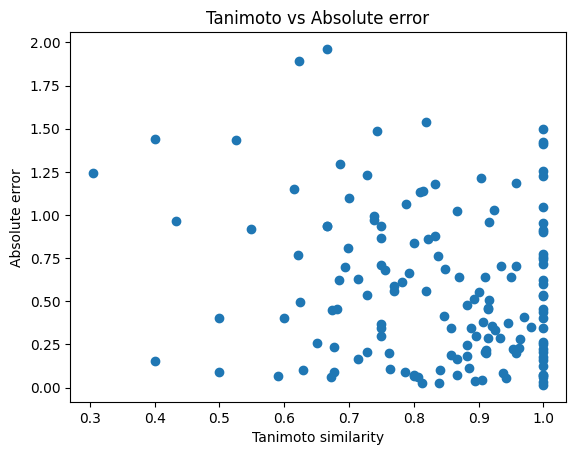

In [157]:
plt.scatter(final_test_df["Tanimoto_Similarity"], final_test_df["Abs_Error"])
plt.xlabel("Tanimoto similarity")
plt.ylabel("Absolute error")
plt.title("Tanimoto vs Absolute error")
plt.show()

#### 5) Predict the Koc and AD for 3 new substances. 

In [158]:
smiles = {'PFOA': 'C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O', 
          'Bisphenol A': 'CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O',
          'Caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'} # or choose your own! 

new_smiles = list(smiles.values())

new_fps = maccs_from_smiles(new_smiles)
new_pred_logkoc = RFR.predict(new_fps)

X_new_fps_bitvec = maccs_fp_from_smiles_as_bitvectors(new_smiles)

new_tanimoto_sim, new_nn = get_tanimoto_nearest_neighbor(
    X_new_fps_bitvec,
    X_train_fps_bitvec
)

new_results = pd.DataFrame({
    "SMILES": new_smiles,
    "Predicted_LogKOC": new_pred_logkoc,
    "Tanimoto_Similarity": new_tanimoto_sim
})

new_results["Inside_AD"] = new_results["Tanimoto_Similarity"] >= ad_threshold

new_results

,SMILES,Predicted_LogKOC,Tanimoto_Similarity,Inside_AD
0,C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F...,0.274286,0.833333,True
1,CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O,2.984520,0.615385,False
2,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,2.303500,0.637931,False


### Questions:
- Which AD metric did you choose, and why?
- How well does your model perform? Can you trust your AD metric?
- Are the new substances within the AD? Can you trust the Koc predictions? 

 - I chose tanimoto similarity as it is made for fingerprints, or rather binary data, which fits perfect with MACCS fingerprints
 - The model achieved a RMSE of 0.718, its an okey prediction error for the size of the data set which is relatively small. But I would argue that it is not the best model for the job. Tanimoto tells me if the test molecule is similar to one of the training molecules, which I trsut to a certain degree. To a certain degree because as we have seen in the lecture, it doesnt really take into account size/Mw for example, giving rather different moelcules with a high tanimoto similarity. So it is a good inital point but I would never fully trust it.
 - One of the compounds are within the AD (I set it to 0.5 or 50%), but I wouldnt trust the Koc predictions as the training was done on the small dataset and the chemical space wasnt that diverse.